# EcoScan: Waste Classification using EfficientNet-B0
### Developed by: Hibba Amir

## Environment Setup and GPU Verification

In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


## Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Extraction

In [19]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/archive"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


## Dataset Path Verification

In [30]:
import os

DATASET_PATH = "/content/archive/content/unified_dataset"

print(os.path.exists(DATASET_PATH))

True


## Dependency Installation

In [6]:
!pip install timm -q

## Verify Dataset

In [31]:
from torchvision import datasets

dataset = datasets.ImageFolder(
    root="/content/archive/content/unified_dataset"
)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['battery', 'glass', 'metal', 'organic_waste', 'paper_cardboard', 'plastic', 'textiles', 'trash']
Total Images: 64000


## Import Libraries

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## Data Augmentation and Preprocessing

In [33]:
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

## Reload Dataset With Transformations

In [34]:
dataset = datasets.ImageFolder(
    root="/content/archive/content/unified_dataset",
    transform=transform
)

print("Total Images:", len(dataset))
print("Classes:", dataset.classes)

Total Images: 64000
Classes: ['battery', 'glass', 'metal', 'organic_waste', 'paper_cardboard', 'plastic', 'textiles', 'trash']


## Split Dataset

In [35]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 51200
Validation: 6400
Test: 6400


## Create DataLoaders

In [36]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Load EfficientNet-B0

In [37]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=8
)

model = model.to(device)

print("EfficientNet-B0 Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet-B0 Loaded Successfully


## Loss Function and Optimizer

In [38]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
)

## Learning Rate Scheduler

In [39]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

## Training Loop

In [40]:
num_epochs = 15

best_val_acc = 0
patience = 5
counter = 0

for epoch in range(num_epochs):

    # TRAINING
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)

        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # VALIDATION
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total

    scheduler.step(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # Save Best Model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_efficientnet_b0.pth"
        )

        counter = 0

        print("Best model saved!")

    else:

        counter += 1

        print(
            f"No improvement ({counter}/{patience})"
        )

        if counter >= patience:

            print("Early stopping triggered")
            break

Epoch [1/15] | Train Acc: 83.60% | Val Acc: 93.88%
Best model saved!
Epoch [2/15] | Train Acc: 95.59% | Val Acc: 96.64%
Best model saved!
Epoch [3/15] | Train Acc: 97.87% | Val Acc: 96.81%
Best model saved!
Epoch [4/15] | Train Acc: 98.51% | Val Acc: 97.58%
Best model saved!
Epoch [5/15] | Train Acc: 98.93% | Val Acc: 97.73%
Best model saved!
Epoch [6/15] | Train Acc: 99.19% | Val Acc: 97.98%
Best model saved!
Epoch [7/15] | Train Acc: 99.17% | Val Acc: 98.19%
Best model saved!
Epoch [8/15] | Train Acc: 99.36% | Val Acc: 97.91%
No improvement (1/5)
Epoch [9/15] | Train Acc: 99.42% | Val Acc: 97.91%
No improvement (2/5)
Epoch [10/15] | Train Acc: 99.43% | Val Acc: 98.23%
Best model saved!
Epoch [11/15] | Train Acc: 99.48% | Val Acc: 98.11%
No improvement (1/5)
Epoch [12/15] | Train Acc: 99.45% | Val Acc: 98.19%
No improvement (2/5)
Epoch [13/15] | Train Acc: 99.55% | Val Acc: 97.98%
No improvement (3/5)
Epoch [14/15] | Train Acc: 99.74% | Val Acc: 98.67%
Best model saved!
Epoch [15/15] 

## Validation Accuracy

In [41]:
print("Best Validation Accuracy:", best_val_acc)

Best Validation Accuracy: 98.6875


## Test Accuracy

In [42]:
# Load best model

model.load_state_dict(
    torch.load(
        "best_efficientnet_b0.pth",
        map_location=device
    )
)

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

test_acc = 100 * correct / total

print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 98.56%


## Classification Report

In [43]:
from sklearn.metrics import classification_report
import numpy as np

all_labels = []
all_preds = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())

        all_preds.extend(
            preds.cpu().numpy()
        )

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    )
)

                 precision    recall  f1-score   support

        battery       1.00      1.00      1.00       802
          glass       0.98      0.98      0.98       784
          metal       0.99      0.99      0.99       842
  organic_waste       0.99      0.99      0.99       822
paper_cardboard       0.98      0.98      0.98       817
        plastic       0.97      0.96      0.97       750
       textiles       0.99      0.98      0.99       789
          trash       0.99      1.00      0.99       794

       accuracy                           0.99      6400
      macro avg       0.99      0.99      0.99      6400
   weighted avg       0.99      0.99      0.99      6400



## Confusion Matrix

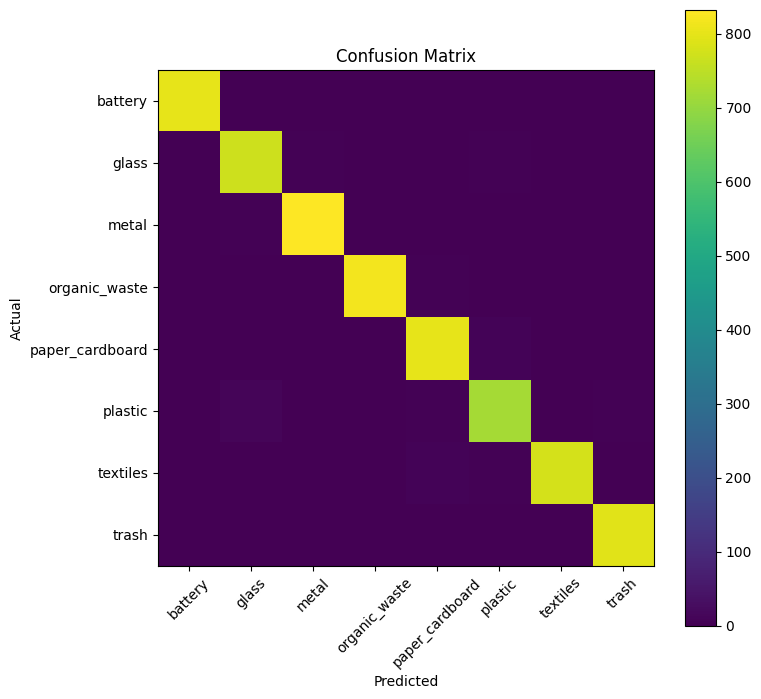

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    np.arange(len(dataset.classes)),
    dataset.classes,
    rotation=45
)

plt.yticks(
    np.arange(len(dataset.classes)),
    dataset.classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Save Trained Model

In [47]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/EfficientNet-B0_Model.pth"
)